/Library/Developer/CommandLineTools/Library/Frameworks/Python3.framework/Versions/3.9/lib/python3.9/pty.py:85: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


(400, 318)
(318,)
(318,)


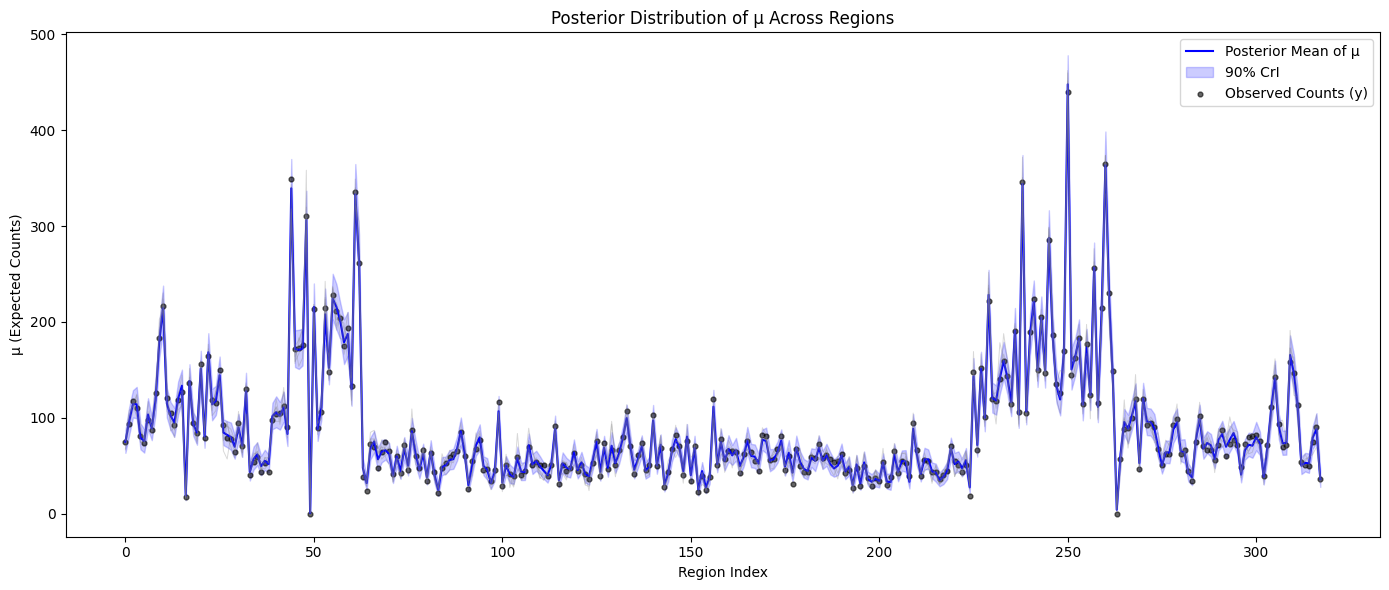

NameError: name 'X' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import sys
import os
!pip install seaborn

# Add the parent directory to sys.path so CAR_model can be imported
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from CAR_model.uk_lung_car import y, E, X

# mcmc_samples is what you get from mcmc.get_samples()
with open("/Users/alydiaowens/uk-lung-model/gp_mcmc_samples.pkl", "rb") as f:
    samples = pickle.load(f)

# Reconstruct mu from posterior f samples
f_samples = samples["f"]  # shape: (n_samples, n_regions)
# Flatten samples across chains and draws
n_chains, n_draws, n_regions = f_samples.shape
f_samples_flat = f_samples.reshape(-1, n_regions)  # shape: (400, 318)
mu_samples = E[None, :] * np.exp(f_samples_flat)  # broadcast E across samples

# Posterior summary
mu_mean = np.mean(mu_samples, axis=0)
mu_lower = np.percentile(mu_samples, 5, axis=0)
mu_upper = np.percentile(mu_samples, 95, axis=0)
print(mu_samples.shape)  # should be (num_samples, num_regions)
print(mu_mean.shape)     # should be (num_regions,)
print(mu_lower.shape)    # should be (num_regions,)


# Plotting
plt.figure(figsize=(14, 6))
region_idx = np.arange(len(y))

plt.plot(region_idx, mu_mean, label="Posterior Mean of μ", color="blue")
plt.fill_between(region_idx, mu_lower, mu_upper, color="blue", alpha=0.2, label="90% CrI")

# Optional: overlay observed counts
plt.scatter(region_idx, y, color="black", alpha=0.6, label="Observed Counts (y)", s=12)

# Optional: show variability with a few posterior draws
for i in np.random.choice(mu_samples.shape[0], size=5, replace=False):
    plt.plot(region_idx, mu_samples[i], color="gray", alpha=0.3, linewidth=0.7)

plt.xlabel("Region Index")
plt.ylabel("μ (Expected Counts)")
plt.title("Posterior Distribution of μ Across Regions")
plt.legend()
plt.tight_layout()
plt.show()


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import multivariate_normal

# Use your squared exponential kernel
def squared_exponential_kernel(x1, x2, length_scale=1.0, variance=1.0):
    sqdist = np.sum(x1**2, axis=1).reshape(-1, 1) + np.sum(x2**2, axis=1) - 2 * np.dot(x1, x2.T)
    return variance * np.exp(-0.5 / length_scale**2 * sqdist)

# === Construct GP prior covariance matrix ===
length_scale = 1.0  # adjust if you want to match your prior
variance = 1.0
noise = 1e-6  # small jitter for stability

K_prior = squared_exponential_kernel(X, X, length_scale=length_scale, variance=variance)
K_prior += noise * np.eye(K_prior.shape[0])  # Add jitter

# === Sample from GP prior ===
n_draws = 500
f_prior = np.random.multivariate_normal(mean=np.zeros(K_prior.shape[0]), cov=K_prior, size=n_draws)
mu_prior = E[None, :] * np.exp(f_prior)  # shape: (n_draws, n_regions)
mu_prior_flat = mu_prior.flatten()

# === Posterior samples already computed ===
f_samples_flat = f_samples.reshape(-1, f_samples.shape[-1])
mu_post = E[None, :] * np.exp(f_samples_flat)
mu_post_flat = mu_post.flatten()

# === PLOT: Prior vs Posterior of μ ===
plt.figure(figsize=(6, 4))

sns.histplot(mu_prior_flat, label='Prior distribution', color='teal', stat='density',
             kde=True, element='step', fill=True, alpha=0.5)
sns.histplot(mu_post_flat, label='Posterior distribution', color='coral', stat='density',
             kde=True, element='step', fill=True, alpha=0.5)

plt.xlabel('μ')
plt.ylabel('Density')
plt.title('Prior vs Posterior Distribution of μ')
plt.legend()
plt.tight_layout()
plt.show()
